<img src='https://github.com/LinkedEarth/Logos/blob/master/Pyleoclim/PYLEOCLIM_logo_HORZ-01.png?raw=true' width="800">

# Basic timeseries manipulation

by [Jordan Landers](0000-0001-9772-7617), [Julien Emile-Geay](https://orcid.org/0000-0001-5920-4751)

## Preamble

Pyleoclim has multiple functionalities to pre-process a timeseries including standardizing, detrending, and interpolation. You can learn about the various pre-processing steps in Notebooks `.ipynb` and `ipynb`. Here, we simply standardize the data and plot it against the original data:

### Goals:

* Learn to specify a slice of a `Series`
* Learn to quickly view summary statistics of a `Series`
* Learn to standardize a `Series`
* Learn to gaussianize a `Series`


**Reading Time:**

5 minutes

### Keywords
Summary Statistics; Standardize; Gaussianize;

### Pre-requisites

None. This tutorial assumes basic knowledge of Python. If you are not familiar with this coding language, check out [this tutorial](http://linked.earth/LeapFROGS/).

### Relevant Packages

Pandas, Seaborn

## Data Description

Sea-surface temperature from [Kaplan (1998)](https://psl.noaa.gov/data/gridded/data.kaplan_sst.html) averaged over the NINO3 (5N-5S, 150W-190E)) region.


## Demonstration
### Load a sample dataset

In [1]:
%load_ext watermark

import pyleoclim as pyleo
import pandas as pd
import seaborn as sns

Pyleoclim ships with a few pre-defined datasets:

In [2]:
pyleo.utils.available_dataset_names()

['SOI',
 'NINO3',
 'HadCRUT5',
 'AIR',
 'LR04',
 'AACO2',
 'EDC-dD',
 'GISP2',
 'cenogrid_d18O',
 'cenogrid_d13C']

Let's load the NINO3 timeseries and plot it: 

(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='Time [year C.E.]', ylabel='NINO3 [$^{\\circ}$C]'>)

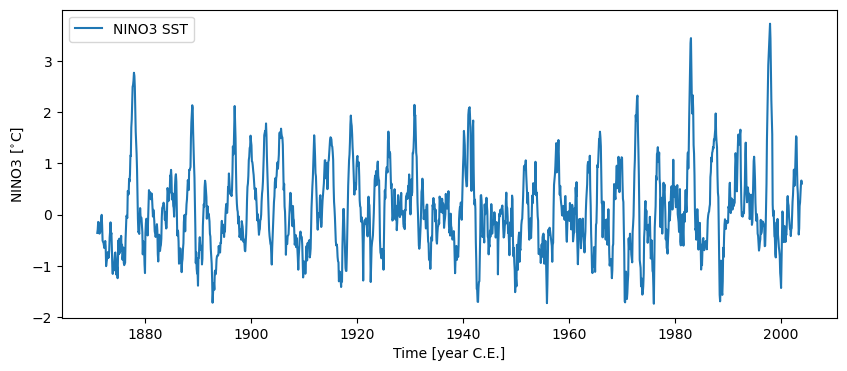

In [3]:
nino3 = pyleo.utils.load_dataset('NINO3')
nino3.plot()

### Slicing
Passing a list containing a pair of dates to `.sel()` will return the time slice of interest. Notice that the syntax involves "slice":

In [4]:
nino_slice = nino3.sel(time=slice(1972, 1998))

<Axes: xlabel='Time [year C.E.]', ylabel='NINO3 [$^{\\circ}$C]'>

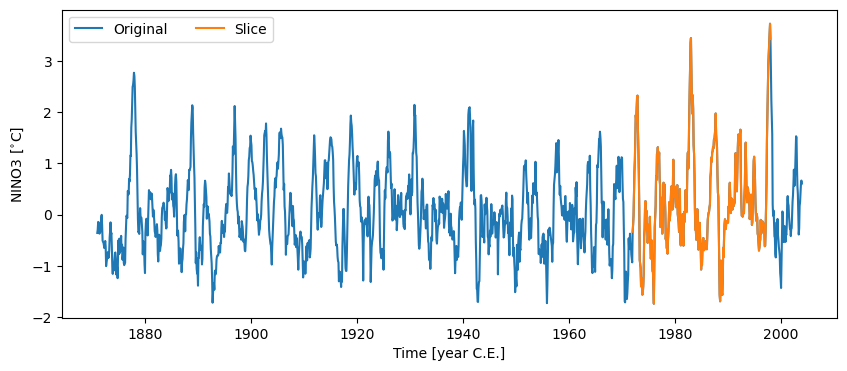

In [5]:
fig, ax = nino3.plot(label='Original')
nino_slice.plot(label='Slice', color='C1', ax=ax, lgd_kwargs={'ncol': 2})

### Stats
Calling `.stats()` will return a handy dictionary of summary statistics (mean, median, min, max, standard deviation, and the interquartile range ([IQR](https://en.wikipedia.org/wiki/Interquartile_range)))

In [6]:
nino3.stats()

{'mean': np.float64(0.07816584993045111),
 'median': np.float64(-0.022333334),
 'min': np.float64(-1.739667),
 'max': np.float64(3.724903),
 'std': np.float64(0.8216852391762094),
 'IQR': np.float64(1.015916675)}

Or you could do it the pandas way:

In [7]:
nino3.to_pandas().describe()

count    1596.000000
mean        0.078166
std         0.821943
min        -1.739667
25%        -0.487979
50%        -0.022333
75%         0.527937
max         3.724903
Name: NINO3, dtype: float64

### Standardizing
Calling `.standardize()` subtracts the mean of the series and divides by the standard deviation.

In [8]:
nino3_std = nino3.standardize()
nino3_std.label = nino3.label + ', standardized' 
nino3_std.stats()

{'mean': np.float64(1.3356066461656018e-17),
 'median': np.float64(-0.12230861543917694),
 'min': np.float64(-2.212322630686346),
 'max': np.float64(4.438119338404606),
 'std': np.float64(0.9999999999999998),
 'IQR': np.float64(1.2363817999438809)}

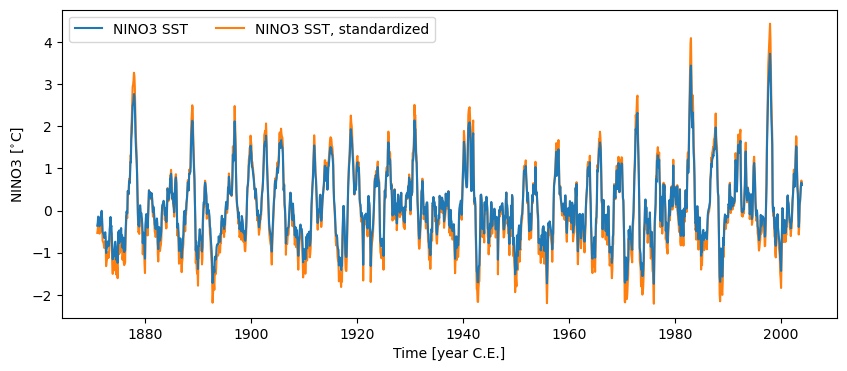

In [9]:
fig, ax = nino3.plot(zorder=99) # this high zorder ensures that it plots on top
ax = nino3_std.plot(ax=ax, lgd_kwargs={'ncol': 2})

### Gaussianize
Calling `.gaussianize()` maps the series to a standard Gaussian distribution. Not only will it have  unit standard deviation ($\sigma=1$), a mean (and median) of 0, but its distribution is now the famed Bell Curve. This may be useful for methods that require data to be normally distributed.

In [10]:
nino3_gaus = nino3.gaussianize()
nino3_gaus.label = nino3.label + ', Gaussianized' 
nino3_gaus.stats()

{'mean': np.float64(1.7808088615541357e-17),
 'median': np.float64(0.0),
 'min': np.float64(-3.419845799144218),
 'max': np.float64(3.419845799144218),
 'std': np.float64(0.9995910124024003),
 'IQR': np.float64(1.347994295650057)}

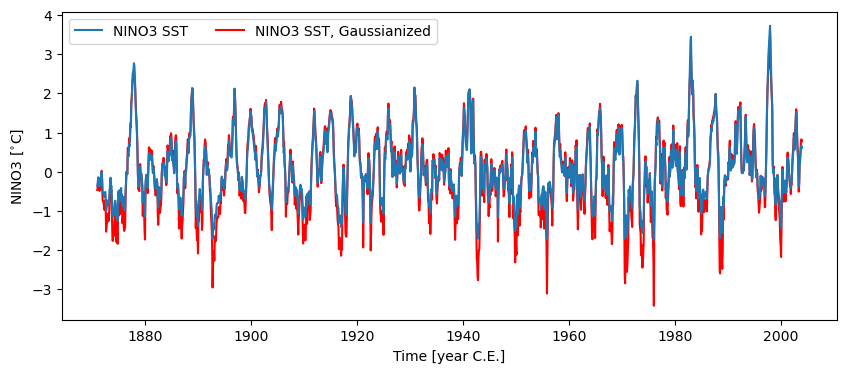

In [11]:
fig, ax = nino3.plot(zorder=99)
ax = nino3_gaus.plot(ax=ax, lgd_kwargs={'ncol': 2}, **{'color':'red'})

Plotting all of them together:

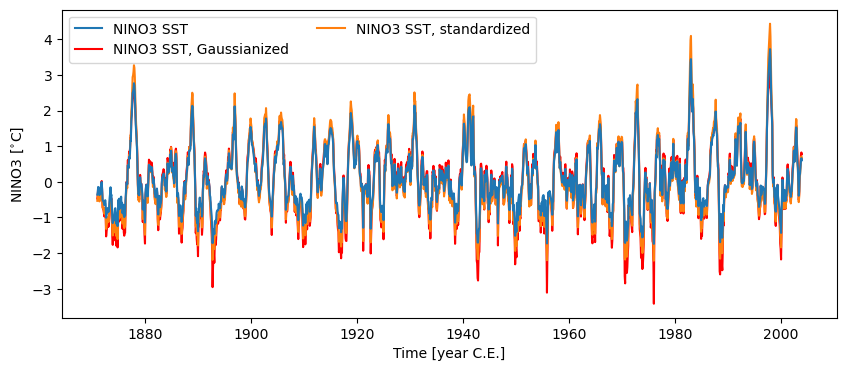

In [12]:
fig, ax = nino3.plot(zorder=99)
ax = nino3_gaus.plot(ax=ax, lgd_kwargs={'ncol': 2}, **{'color':'red'})
ax = nino3_std.plot(ax=ax, lgd_kwargs={'ncol': 2})

### Comparison
For context, it is interesting to compare the different treatments. [Seaborn](https://seaborn.pydata.org/index.html) is a very useful plotting library that works very nicely with [Pandas](https://pandas.pydata.org). To produce this quick comparison, we will gather those 3 Series into a [MultipleSeries object](L0_basic_MSES_manipulation.md) and export it to a [Pandas DataFrame](https://pandas.pydata.org/docs/reference/frame.html). Seaborn will happily ingest this dataframe and return a [kernel density plot](https://seaborn.pydata.org/generated/seaborn.kdeplot.html) summarizing the probability density of the data values in each treatment. 

In [13]:
nino_ms =  nino3 & nino3_gaus & nino3_std
nino_df = nino_ms.to_pandas()
nino_df

The two series have values differing by more than 1e-05 $^{\circ}$C
Metadata are different:
label property -- left: NINO3 SST, right: NINO3 SST, standardized
The two series have values differing by more than 1e-05 $^{\circ}$C
Metadata are different:
label property -- left: NINO3 SST, Gaussianized, right: NINO3 SST, standardized


,NINO3 SST,"NINO3 SST, Gaussianized","NINO3 SST, standardized"
datetime,,,
1870-12-31 03:41:38,-0.358250,-0.468084,-0.531123
1871-01-30 14:10:31,-0.292458,-0.377045,-0.451054
1871-03-02 00:39:56,-0.143583,-0.166461,-0.269871
1871-04-01 11:08:49,-0.149625,-0.185602,-0.277224
1871-05-01 21:37:43,-0.274250,-0.348528,-0.428894
...,...,...,...
2003-08-01 04:22:03,0.238497,0.361911,0.195125
2003-08-31 14:51:28,0.411449,0.543054,0.405609
2003-10-01 01:20:21,0.592756,0.752493,0.626262


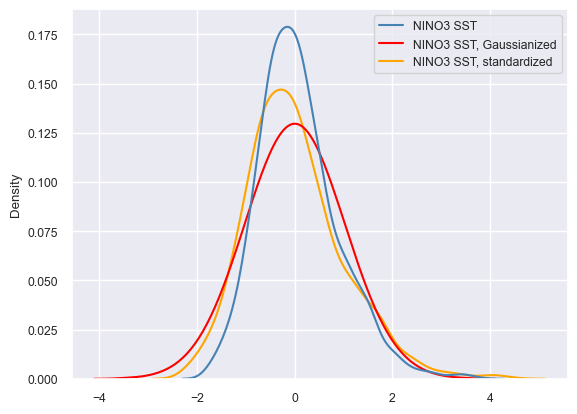

In [14]:
sns.set(font_scale=0.8)
ax = sns.kdeplot(data=nino_df, palette={'NINO3 SST':'steelblue', 'NINO3 SST, Gaussianized':'red', 'NINO3 SST, standardized':'orange'})
ax.legend_.set_title(None)

In [15]:
%watermark -n -u -v -iv -w

Last updated: Thu, 12 Mar 2026

Python implementation: CPython
Python version       : 3.12.11
IPython version      : 9.6.0

pandas   : 2.3.3
pyleoclim: 1.2.1b0
seaborn  : 0.13.2

Watermark: 2.6.0

